In [1]:
#Random Forest untuk Klasifikasi

#Load & Eksplorasi Data

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_recall_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

#Load dataset (UCI Bank Marketing Dataset)
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
url = "https://archive.ics.uci.edu/static/public/222/bank-additional.zip"
# Download manually atau gunakan dataset dari sklearn
from sklearn.datasets import fetch_openml

#Option 1: Gunakan fetch_openml
bank = fetch_openml(data_id=1461, as_frame=True) #bank-marketing dataset
df = bank.frame

print("Dataset Info: ")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())
print(f"\nTarget Distribution (y/Class):")
print(df['Class'].value_counts())
print(df['Class'].unique())
print(df['Class'].dtype)

#Preprocessing
#Encode categorical variables
categorical_cols = df.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    if col != 'Class':
        df[col] = LabelEncoder().fit_transform(df[col])

#Encode target
df['Class'] = (df['Class'] == '2').astype(int)

#Split features and target
X = df.drop('Class', axis=1)
y = df['Class']
print(y)

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in Train: {y_train.value_counts().to_dict()}")

Dataset Info: 
Shape: (45211, 17)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'Class']
   V1            V2       V3         V4  V5    V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143  yes   no  unknown    5   
1  44    technician   single  secondary  no    29  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1   no   no  unknown    5   

   V11  V12  V13  V14  V15      V16 Class  
0  may  261    1   -1    0  unknown     1  
1  may  151    1   -1    0  unknown     1  
2  may   76    1   -1    0  unknown     1  
3  may   92    1   -1    0  unknown     1  
4  may  198    1   -1    0  unknown     1  

Target Distribution (y/Class):
Class
1    39922
2     5289
Name: count, dtype: int64
['1', '2']
Categories (2, str):

=== RANDOM FOREST CLASSIFIER ===
Train Accuracy: 1.0000
Test Accuracy : 0.9063
Test F1-Score : 0.5101
Test AUC-ROC  : 0.9246

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7985
         Yes       0.66      0.42      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043

cm: [[7755  230]
 [ 617  441]]


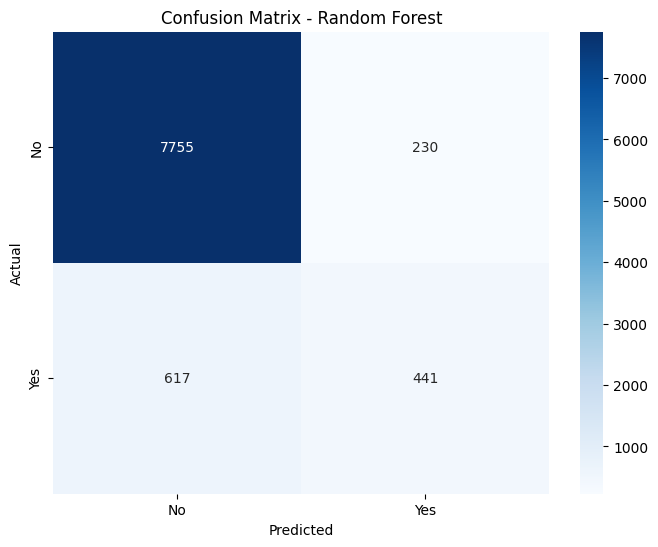

In [2]:
# Train Random Forest Classifier

#Initialize model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#Train model
rf_clf.fit(X_train, y_train)

#Predictions
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)
y_test_proba = rf_clf.predict_proba(X_test)[:, 1]

#Evaluation
print("=== RANDOM FOREST CLASSIFIER ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1-Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"Test AUC-ROC  : {roc_auc_score(y_test, y_test_proba):.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No','Yes']))

#Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"cm: {cm}")
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Top 10 Feature Importance:
   feature  importance
11     V12    0.291153
5       V6    0.110084
0       V1    0.103281
9      V10    0.090262
10     V11    0.087403
15     V16    0.055356
13     V14    0.048788
1       V2    0.048493
12     V13    0.038565
3       V4    0.027879


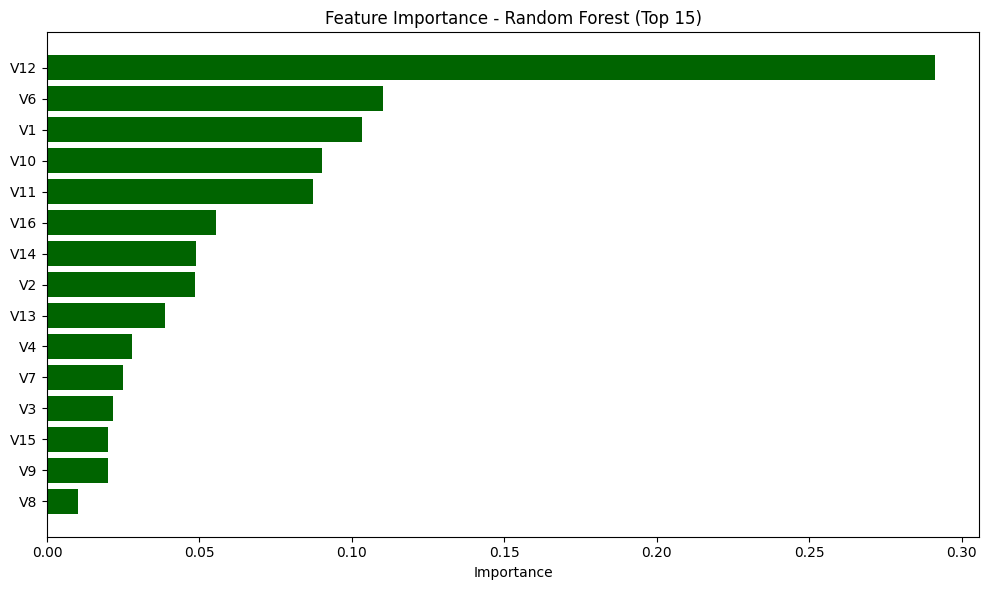


=== INSIGHT ===
Fitur paling penting: durasi kontak telepon terakhir
Interpretasi: Semakin lama nasabah diajak bicara, semakin besar minat berlangganan


In [3]:
#Feature Importance

#Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance' : rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Feature Importance:")
print(feature_importance.head(10).sort_values('importance', ascending=False))

#Visualize
plt.figure(figsize=(10,6))
plt.barh(feature_importance.head(15)['feature'],
            feature_importance.head(15)['importance'], color='darkgreen')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Insight interpretation
print("\n=== INSIGHT ===")
print("Fitur paling penting: durasi kontak telepon terakhir")
print("Interpretasi: Semakin lama nasabah diajak bicara, semakin besar minat berlangganan")

Kolom	Nama Asli
V1	age
V2	job
V3	marital
V4	education
V5	default
V6	balance
V7	housing
V8	loan
V9	contact
V10	day
V11	month
V12	duration
V13	campaign
V14	pdays
V15	previous
V16	poutcome
Class	y

In [4]:
param_grid = {
    'n_estimators' : [50,100,200],
    'max_depth' : [10,20, None],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
}

#Grid search with cross-validation
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best Parameters:", grid_search.best_params_)
print("Best CV AUC-ROC: {:.4f}".format(grid_search.best_score_))

#Evaluate best model on test set
best_rf = grid_search.best_estimator_
y_test_pred_best = best_rf.predict(X_test)
y_test_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"\nBest Model Test AUC-ROC: {roc_auc_score(y_test, y_test_proba_best):.4f}")
print(f"Improvement: {(roc_auc_score(y_test, y_test_proba_best) - roc_auc_score(y_test, y_test_proba))*100:.2f}%")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV AUC-ROC: 0.9297

Best Model Test AUC-ROC: 0.9281
Improvement: 0.36%


In [25]:
print(f"Improvement: {(roc_auc_score(y_test, y_test_proba_best) - roc_auc_score(y_test, y_test_proba))*100:.2f}%")

Improvement: 0.36%


In [26]:
#Out-of-Bag (OOB) Score
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (internal validation): {rf_oob.oob_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")
print("Note: OOB score adalah validasi internal tanpa perlu validation set!")

OOB Score (internal validation): 0.9031
Test Accuracy: 0.9063
Note: OOB score adalah validasi internal tanpa perlu validation set!


In [27]:
#PR 1: Hyperparameter Optimization dengan RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid_random = {
    'n_estimators' : [50,100,200,300,500],
    'max_depth' : [10,20,30,None],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4],
    'bootstrap' : [True, False]
}

#Randomized search dengan cross-validation
rf_random = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf_random, param_distributions=param_grid_random, n_iter=20, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2, random_state=42
)
random_search.fit(X_train, y_train)

print(f"Best Parameters (Randomized Search):", random_search.best_params_)
print("Best CV AUC-ROC (Randomized Search): {:.4f}".format(random_search.best_score_))

#Evaluate best model from RandomizedSearchCV on test set
best_rf_random = random_search.best_estimator_
y_test_pred_best_random = best_rf_random.predict(X_test)
y_test_proba_best_random = best_rf_random.predict_proba(X_test)[:, 1]

print(f"\nBest Model (Randomized Search) Test AUC-ROC: {roc_auc_score(y_test, y_test_proba_best_random):.4f}")
print(f"Improvement (Randomized Search): {(roc_auc_score(y_test, y_test_proba_best_random) - roc_auc_score(y_test, y_test_proba))*100:.2f}%")



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters (Randomized Search): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None, 'bootstrap': False}
Best CV AUC-ROC (Randomized Search): 0.9303

Best Model (Randomized Search) Test AUC-ROC: 0.9289
Improvement (Randomized Search): 0.43%


In [37]:
#PR2 : Feature Engineering
new_df = df.copy()
# new_df['duration_per_call'] = np.where(new_df['V15'] > 0, new_df['V12'] / (new_df['V15']), 0) #durasi per panggilan
new_df['duration_per_call'] = df['V12'] / (df['V15'] + 1) #durasi per panggilan, tambahkan 1 untuk hindari pembagian dengan nol

print("Dataset Info after Feature Engineering: ")
print(f"Shape: {new_df.shape}")
print(f"Columns: {new_df.columns.tolist()}")
print(new_df.head())
print(f"\nTarget Distribution (y/Class):")
print(new_df['Class'].value_counts())
print(new_df['Class'].unique())
print(new_df['Class'].dtype)

#Preprocessing
#Encode categorical variables
categorical_cols_new = new_df.select_dtypes(include=['object','category']).columns
for col in categorical_cols_new:
    if col != 'Class':
        new_df[col] = LabelEncoder().fit_transform(new_df[col])

#Encode target
# new_df['Class'] = (new_df['Class'] == '2').astype(int)

#Split features and target
X_new = new_df.drop('Class', axis=1)
y_new = new_df['Class']
print(y_new)

#Train-test split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

print(f"\nTraining set: {X_train_new.shape}")
print(f"Test set: {X_test_new.shape}")
print(f"Class distribution in Train: {y_train_new.value_counts().to_dict()}")
print(f"Class distribution in Test: {y_test_new.value_counts().to_dict()}")




Dataset Info after Feature Engineering: 
Shape: (45211, 18)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'Class', 'duration_per_call']
   V1  V2  V3  V4  V5    V6  ...  V13  V14  V15  V16  Class  duration_per_call
0  58   4   1   2   0  2143  ...    1   -1    0    3      0              261.0
1  44   9   2   1   0    29  ...    1   -1    0    3      0              151.0
2  33   2   1   1   0     2  ...    1   -1    0    3      0               76.0
3  47   1   1   3   0  1506  ...    1   -1    0    3      0               92.0
4  33  11   2   3   0     1  ...    1   -1    0    3      0              198.0

[5 rows x 18 columns]

Target Distribution (y/Class):
Class
0    39922
1     5289
Name: count, dtype: int64
[0 1]
int64
0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: Class, Length: 45211, dtype: int64

Training set: (36168, 17)
Test set: (90

=== RANDOM FOREST CLASSIFIER (with New Features) ===
Train Accuracy: 1.0000
Test Accuracy : 0.9052
Test F1-Score : 0.5055
Test AUC-ROC  : 0.9216

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7985
         Yes       0.65      0.41      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043

cm: [[7748  237]
 [ 620  438]]


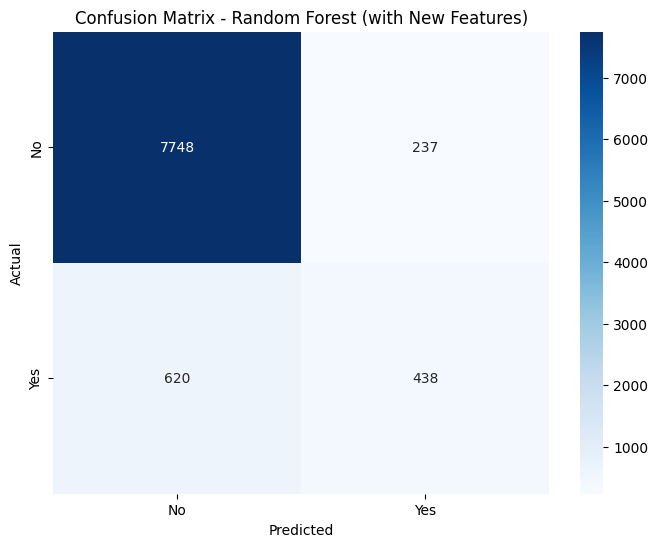

In [38]:
#Train model dengan fitur baru

#initialize model
rf_clf_new = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#Train model
rf_clf_new.fit(X_train_new, y_train_new)

#Predictions
y_train_pred_new = rf_clf_new.predict(X_train_new)
y_test_pred_new = rf_clf_new.predict(X_test_new)
y_test_proba_new = rf_clf_new.predict_proba(X_test_new)[:, 1]

#Evaluation
print("=== RANDOM FOREST CLASSIFIER (with New Features) ===")
print(f"Train Accuracy: {accuracy_score(y_train_new, y_train_pred_new):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test_new, y_test_pred_new):.4f}")
print(f"Test F1-Score : {f1_score(y_test_new, y_test_pred_new):.4f}")
print(f"Test AUC-ROC  : {roc_auc_score(y_test_new, y_test_proba_new):.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test_new, y_test_pred_new, target_names=['No','Yes']))

#Confusion Matrix
cm_new = confusion_matrix(y_test_new, y_test_pred_new)
print(f"cm: {cm_new}")
plt.figure(figsize=(8,6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (with New Features)')
plt.show()

Top 10 Feature Importance (with New Features):
              feature  importance
11                V12    0.187621
16  duration_per_call    0.158308
5                  V6    0.095133
0                  V1    0.094028
9                 V10    0.081404
10                V11    0.080351
15                V16    0.053559
13                V14    0.048112
1                  V2    0.043840
12                V13    0.034372


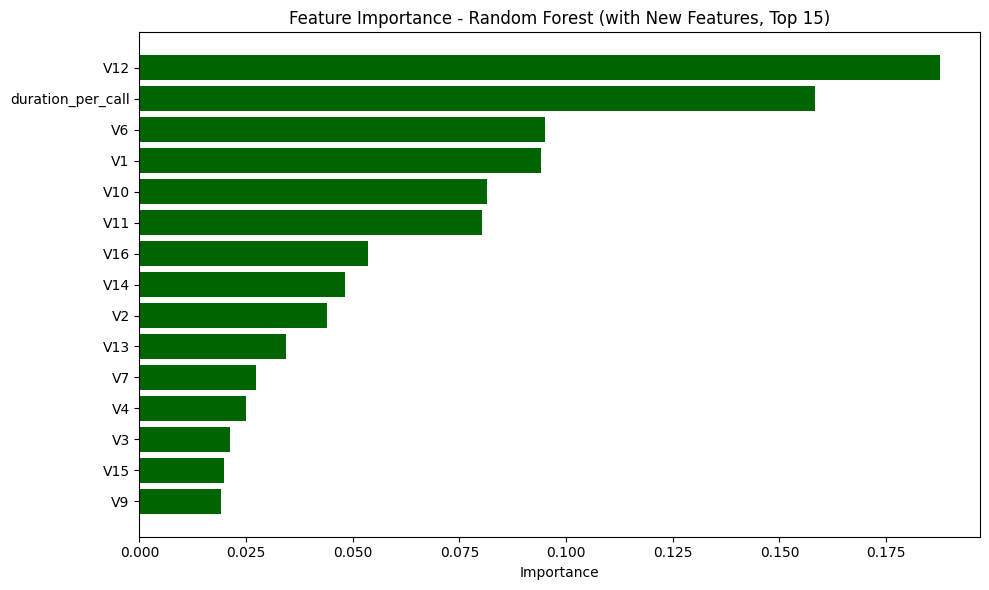


=== INSIGHT (with New Features) ===
Fitur paling penting: durasi kontak telepon terakhir
Interpretasi: Semakin lama nasabah diajak bicara, semakin besar minat berlangganan


In [39]:
#Feature Importance

#Get feature importance
feature_importance_new = pd.DataFrame({
    'feature': X_new.columns,
    'importance' : rf_clf_new.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Feature Importance (with New Features):")
print(feature_importance_new.head(10).sort_values('importance', ascending=False))

#Visualize
plt.figure(figsize=(10,6))
plt.barh(feature_importance_new.head(15)['feature'],
            feature_importance_new.head(15)['importance'], color='darkgreen')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (with New Features, Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Insight interpretation
print("\n=== INSIGHT (with New Features) ===")
print("Fitur paling penting: durasi kontak telepon terakhir")
print("Interpretasi: Semakin lama nasabah diajak bicara, semakin besar minat berlangganan")

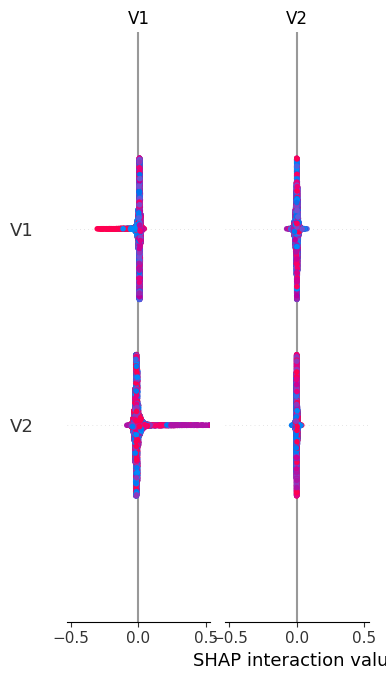

In [40]:
# SHAP (SHapley Additive exPlanations) untuk interpretasi model
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

(9043, 16, 2)


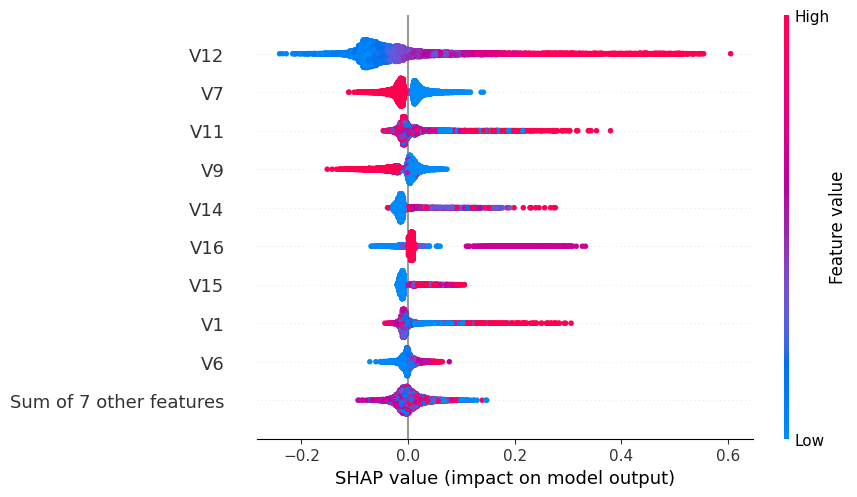

In [7]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer(X_test)

print(shap_values.shape)

shap.plots.beeswarm(shap_values[:,:,1])